# Conformal Coverage: IID Versus Covariate Shift

**Research question.** When does a nominal 90% prediction interval stop covering 90% of outcomes?

Original controlled experiment by Zangar. This notebook runs offline and uses synthetic data, never real personal records. [Source and reproduction instructions](https://github.com/zoga228/validation-stress-lab).

AI tools assisted implementation and editing; all reported measurements come from executed code.

## Experimental protocol

Fit a regressor on 4000 training rows. Calibrate absolute-residual intervals on 2000 independent rows using the finite-sample order statistic ceil((n+1)(1-alpha)). Evaluate three confidence levels on 3000 IID and 3000 shifted rows. We deliberately use constant-width intervals despite heteroscedastic noise to distinguish marginal and conditional coverage.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
import numpy as np, pandas as pd, sklearn, matplotlib
print({'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__,'matplotlib':matplotlib.__version__})

{'numpy': '2.2.6', 'pandas': '2.3.1', 'sklearn': '1.7.1', 'matplotlib': '3.10.6'}


## Data-generating process

The generator is included so every assumption is inspectable. A downloadable CSV version is attached; the seeds below regenerate the same benchmark without file-path dependencies. Synthetic results illustrate a failure mode and do not establish performance on real data.

In [2]:
"""Original synthetic benchmarks; no real people, records, or competition data."""
import json
from pathlib import Path
import numpy as np
import pandas as pd


def grouped(seed=42, groups=400, repeats=30):
    rng = np.random.default_rng(seed)
    ids = np.repeat(np.arange(groups), repeats)
    latent = rng.integers(0, 2, size=groups)
    flip = rng.random(len(ids)) < .08
    return pd.DataFrame({"group_id": ids.astype(str), "sensor_noise": rng.normal(size=len(ids)), "target": np.logical_xor(latent[ids], flip).astype(int)})


def missingness(seed=42, n=6000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, 6))
    score = 1.6*x[:, 0] - .8*x[:, 1] + .5*x[:, 2]*x[:, 3]
    y = (rng.random(n) < 1 / (1 + np.exp(-score))).astype(int)
    # An apparent signal reverses at deployment. This is a controlled stress test.
    correlated = (y + rng.normal(0, .4, n)) if not shifted else ((1-y) + rng.normal(0, .4, n))
    missing = rng.random(n) < np.where(y == 1, .3 if not shifted else .7, .1 if not shifted else .4)
    x[missing, 0] = np.nan
    df = pd.DataFrame(x, columns=[f"x{i}" for i in range(6)])
    df["spurious"] = correlated
    df["target"] = y
    return df


def regression(seed=42, n=4000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(1.8 if shifted else 0, 1, n)
    sigma = .3 + .4*np.abs(x)
    y = np.sin(2*x) + .5*x + sigma*rng.normal(size=n)
    return pd.DataFrame({"x": x, "target": y})


def export(root):
    root = Path(root)
    specs = {
        "grouped-validation": {"all.csv": grouped()},
        "missingness-shift": {"train.csv": missingness(42), "iid-test.csv": missingness(43, 3000), "shift-test.csv": missingness(44, 3000, True)},
        "conformal-shift": {"train.csv": regression(42), "calibration.csv": regression(43, 2000), "iid-test.csv": regression(44, 3000), "shift-test.csv": regression(45, 3000, True)},
    }
    for name, files in specs.items():
        folder = root / name
        folder.mkdir(parents=True, exist_ok=True)
        for filename, frame in files.items():
            frame.to_csv(folder / filename, index=False)
        info = {"synthetic": True, "license": "CC0-1.0", "generator": "make_data.py", "version": "1.0", "files": {k: {"rows": len(v), "columns": list(v)} for k, v in files.items()}, "purpose": "Controlled experiments about validation assumptions; not evidence about a real population"}
        (folder / "data-card.json").write_text(json.dumps(info, indent=2))
        print(name, info["files"])




## Fit and evaluate

Run the complete analysis. Seeds, model settings, and saved tables are explicit.

IID |x| <= 1 90% interval coverage 0.9630541871921182 n= 2030
IID |x| > 1 90% interval coverage 0.7329896907216494 n= 970
covariate shift |x| <= 1 90% interval coverage 0.9441786283891547 n= 627
covariate shift |x| > 1 90% interval coverage 0.6232616940581542 n= 2373
         domain  target_coverage  coverage  mean_width  n_test
            IID             0.95  0.943333    2.721159    3000
            IID             0.90  0.888667    2.136374    3000
            IID             0.80  0.784000    1.552043    3000
covariate shift             0.95  0.783333    2.721159    3000
covariate shift             0.90  0.690333    2.136374    3000
covariate shift             0.80  0.562667    1.552043    3000


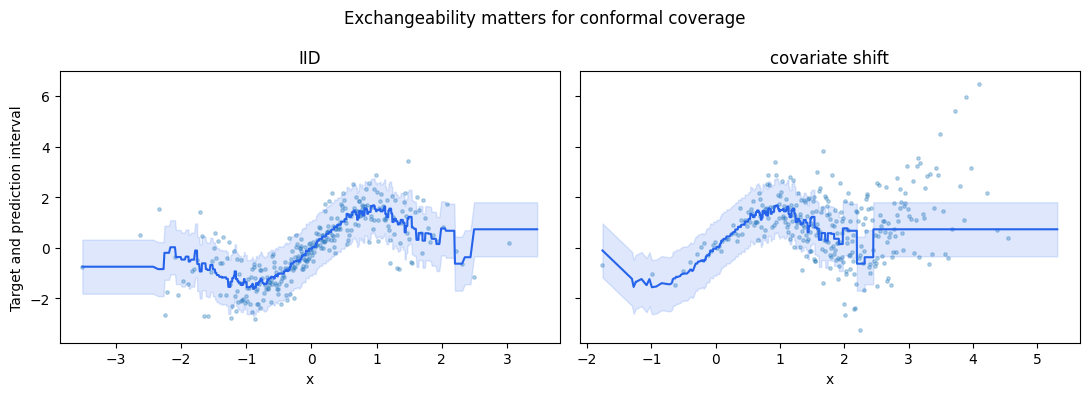

In [3]:
"""Finite-sample split conformal: marginal coverage versus covariate-shift failure."""
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor


def conformal_quantile(scores, alpha):
    k = math.ceil((len(scores)+1)*(1-alpha))
    if k > len(scores):
        return float("inf")
    return float(np.sort(scores)[k-1])


def run():
    train,cal=regression(42),regression(43,2000)
    model=HistGradientBoostingRegressor(max_iter=150,max_leaf_nodes=15,l2_regularization=2,random_state=42).fit(train[["x"]],train.target)
    residual=np.abs(cal.target.to_numpy()-model.predict(cal[["x"]]))
    rows=[]
    fig,axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
    for ax,(domain,test) in zip(axes,(("IID",regression(44,3000)),("covariate shift",regression(45,3000,True)))):
        pred=model.predict(test[["x"]])
        for alpha in (.05,.1,.2):
            q=conformal_quantile(residual,alpha)
            covered=np.abs(test.target.to_numpy()-pred)<=q
            rows.append({"domain":domain,"target_coverage":1-alpha,"coverage":covered.mean(),"mean_width":2*q,"n_test":len(test)})
        q=conformal_quantile(residual,.1)
        order=np.argsort(test.x.to_numpy())
        take=order[::10]
        ax.scatter(test.x.iloc[take],test.target.iloc[take],s=6,alpha=.3)
        ax.plot(test.x.iloc[order],pred[order],color="#2563eb")
        ax.fill_between(test.x.iloc[order],pred[order]-q,pred[order]+q,alpha=.15,color="#2563eb")
        ax.set(title=domain,xlabel="x")
        # Conditional coverage is diagnostic; split conformal does not promise it.
        for label,mask in (("|x| <= 1",np.abs(test.x.to_numpy())<=1),("|x| > 1",np.abs(test.x.to_numpy())>1)):
            print(domain,label,"90% interval coverage",np.mean((np.abs(test.target.to_numpy()-pred)<=q)[mask]),"n=",mask.sum())
    result=pd.DataFrame(rows);print(result.to_string(index=False))
    axes[0].set_ylabel("Target and prediction interval");fig.suptitle("Exchangeability matters for conformal coverage");fig.tight_layout()
    out=Path("outputs");out.mkdir(exist_ok=True)
    result.to_csv(out / "conformal.csv",index=False)
    fig.savefig(out / "conformal.png",dpi=160);plt.show()
    return result


results = run()

## Interpretation and limitations

At nominal 90%, this run gives about 88.9% IID coverage and 69.0% shifted coverage. Finite test samples fluctuate around population coverage. Even under IID sampling, conditional coverage for large |x| is much lower than for small |x|. Split conformal relies on exchangeability and supplies a marginal guarantee; it does not automatically guarantee conditional or shifted-population coverage.

**Reference:** https://arxiv.org/abs/2107.07511

Reproduce first, then adapt the protocol to the population and metric of your own task.